In [1]:
# IMDB Sentiment Analysis: Data Loading and Preprocessing
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/mahirazmainhaque/imdb-dataset/IMDB-Dataset.csv')
print('Dataset shape:', df.shape)
print(df['sentiment'].value_counts())

# Encode sentiment labels
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

# Train-test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['label'], test_size=0.2, stratify=df['label'], random_state=42)
print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])

Dataset shape: (50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64
Train size: 40000
Test size: 10000


## 1. Bag-of-Words (BOW) and TF-IDF Embeddings for LR, SVM

In [2]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

# 300-dimensional BOW
bow_vectorizer = CountVectorizer(max_features=300, stop_words='english')
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

# 300-dimensional TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=300, stop_words='english')
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    precision, recall, f1, _ = precision_recall_fscore_support(y_te, y_pred, average='binary')
    accuracy = accuracy_score(y_te, y_pred)
    return precision, recall, f1, accuracy

# Logistic Regression with BOW
lr_bow = LogisticRegression(max_iter=200)
lr_bow_metrics = evaluate_model(lr_bow, X_train_bow, y_train, X_test_bow, y_test)

# SVM with BOW
svm_bow = LinearSVC()
svm_bow_metrics = evaluate_model(svm_bow, X_train_bow, y_train, X_test_bow, y_test)

# Logistic Regression with TF-IDF
lr_tfidf = LogisticRegression(max_iter=200)
lr_tfidf_metrics = evaluate_model(lr_tfidf, X_train_tfidf, y_train, X_test_tfidf, y_test)

# SVM with TF-IDF
svm_tfidf = LinearSVC()
svm_tfidf_metrics = evaluate_model(svm_tfidf, X_train_tfidf, y_train, X_test_tfidf, y_test)

# Display results
print('Logistic Regression (BOW):', lr_bow_metrics)
print('SVM (BOW):', svm_bow_metrics)
print('Logistic Regression (TF-IDF):', lr_tfidf_metrics)
print('SVM (TF-IDF):', svm_tfidf_metrics)

Logistic Regression (BOW): (0.8132868487313577, 0.8398, 0.8263308078323329, 0.8235)
SVM (BOW): (0.8105040400153906, 0.8426, 0.8262404393018239, 0.8228)
Logistic Regression (TF-IDF): (0.8146341463414634, 0.835, 0.8246913580246914, 0.8225)
SVM (TF-IDF): (0.8121847109041521, 0.8372, 0.8245026590506205, 0.8218)


## 2. Word2Vec and GloVe Embeddings for Bi-LSTM, Bi-GRU

In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, GRU, Dense, Dropout
from tensorflow.keras.models import Sequential
from gensim.models import Word2Vec
import os

# Tokenization and padding
max_words = 20000
max_len = 200
embedding_dim = 300

tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding='post')

# Prepare Word2Vec embeddings
w2v_model = Word2Vec(sentences=[text.split() for text in X_train], vector_size=embedding_dim, window=5, min_count=1, workers=4)
word_index = tokenizer.word_index
embedding_matrix = np.zeros((max_words, embedding_dim))
for word, i in word_index.items():
    if i < max_words:
        if word in w2v_model.wv:
            embedding_matrix[i] = w2v_model.wv[word]

# GloVe embeddings (download glove.6B.300d.txt and place in workspace)
glove_path = 'glove.6B.300d.txt'
glove_embeddings = {}
if os.path.exists(glove_path):
    with open(glove_path, encoding='utf8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            coefs = np.asarray(values[1:], dtype='float32')
            glove_embeddings[word] = coefs
    embedding_matrix_glove = np.zeros((max_words, embedding_dim))
    for word, i in word_index.items():
        if i < max_words:
            vec = glove_embeddings.get(word)
            if vec is not None:
                embedding_matrix_glove[i] = vec
else:
    embedding_matrix_glove = None
    print('GloVe file not found. Skipping GloVe embedding.')

2026-03-16 00:54:31.671555: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773622471.862461      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773622471.916346      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773622472.415181      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773622472.415211      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773622472.415214      55 computation_placer.cc:177] computation placer alr

In [6]:
def build_bilstm_model(embedding_matrix, trainable=False):
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=trainable),
        Bidirectional(LSTM(64, return_sequences=False)),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def build_bigru_model(embedding_matrix, trainable=False):
    model = Sequential([
        Embedding(input_dim=max_words, output_dim=embedding_dim, weights=[embedding_matrix], input_length=max_len, trainable=trainable),
        Bidirectional(GRU(64, return_sequences=False)),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def evaluate_dl_model(model, X_te, y_te):
    y_pred = (model.predict(X_te) > 0.5).astype('int32')
    precision = precision_score(y_te, y_pred)
    recall = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    accuracy = accuracy_score(y_te, y_pred)
    return precision, recall, f1, accuracy

In [13]:
# Train and evaluate Bi-LSTM and Bi-GRU with Word2Vec embeddings
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

bilstm_w2v = build_bilstm_model(embedding_matrix)
bilstm_w2v.fit(X_train_pad, y_train, epochs=6, batch_size=128, validation_split=0.1, verbose=1, callbacks=[early_stop])
bilstm_w2v_metrics = evaluate_dl_model(bilstm_w2v, X_test_pad, y_test)

bigru_w2v = build_bigru_model(embedding_matrix)
bigru_w2v.fit(X_train_pad, y_train, epochs=6, batch_size=128, validation_split=0.1, verbose=1, callbacks=[early_stop])
bigru_w2v_metrics = evaluate_dl_model(bigru_w2v, X_test_pad, y_test)

# Train and evaluate Bi-LSTM and Bi-GRU with GloVe embeddings (if available)
if embedding_matrix_glove is not None:
    bilstm_glove = build_bilstm_model(embedding_matrix_glove)
    bilstm_glove.fit(X_train_pad, y_train, epochs=8, batch_size=128, validation_split=0.1, verbose=1, callbacks=[early_stop])
    bilstm_glove_metrics = evaluate_dl_model(bilstm_glove, X_test_pad, y_test)

    bigru_glove = build_bigru_model(embedding_matrix_glove)
    bigru_glove.fit(X_train_pad, y_train, epochs=8, batch_size=128, validation_split=0.1, verbose=1, callbacks=[early_stop])
    bigru_glove_metrics = evaluate_dl_model(bigru_glove, X_test_pad, y_test)
else:
    bilstm_glove_metrics = bigru_glove_metrics = None

Epoch 1/6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.6879 - loss: 0.5659 - val_accuracy: 0.8528 - val_loss: 0.3536
Epoch 2/6
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8575 - loss: 0.3407 - val_accuracy: 0.8668 - val_loss: 0.3094
Epoch 3/6
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8816 - loss: 0.2968 - val_accuracy: 0.8737 - val_loss: 0.2974
Epoch 4/6
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8864 - loss: 0.2748 - val_accuracy: 0.8763 - val_loss: 0.2904
Epoch 5/6
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8980 - loss: 0.2526 - val_accuracy: 0.8852 - val_loss: 0.2771
Epoch 6/6
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.9087 - loss: 0.2288 - val_accuracy: 0.8932 - val_loss: 0.2590
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Epoch 1/6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.6270 - loss: 0.6317 - val_accuracy: 0.8595 - val_loss: 0.3316
Epoch 2/6
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.8608 - loss: 0.3302 - val_accuracy: 0.8665 - val_loss: 0.3085
Epoch 3/6
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.8912 - loss: 0.2692 - val_accuracy: 0.8838 - val_loss: 0.2763
Epoch 4/6
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9017 - loss: 0.2439 - val_accuracy: 0.9003 - val_loss: 0.2405
Epoch 5/6
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9128 - loss: 0.2180 - val_accuracy: 0.8992 - val_loss: 0.2384
Epoch 6/6
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9208 - loss: 0.2025 - val_accuracy: 0.9055 - val_loss: 0.2370
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Epoch 1/8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.6581 - loss: 0.6125 - val_accuracy: 0.7993 - val_loss: 0.4565
Epoch 2/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8137 - loss: 0.4292 - val_accuracy: 0.8415 - val_loss: 0.3624
Epoch 3/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8517 - loss: 0.3561 - val_accuracy: 0.8440 - val_loss: 0.3514
Epoch 4/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8662 - loss: 0.3167 - val_accuracy: 0.8742 - val_loss: 0.3050
Epoch 5/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8783 - loss: 0.3009 - val_accuracy: 0.8785 - val_loss: 0.2869
Epoch 6/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8928 - loss: 0.2696 - val_accuracy: 0.8835 - val_loss: 0.2838
Epoch 7/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.8989 - loss: 0.2569 - val_accuracy: 0.8805 - val_loss: 0.2696
Epoch 8/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 27ms/step - accuracy: 0.9066 - loss: 0.2372 - val_accuracy: 0.8827 - va

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


282/282 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.6379 - loss: 0.6112 - val_accuracy: 0.8415 - val_loss: 0.3740
Epoch 2/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.8579 - loss: 0.3380 - val_accuracy: 0.8535 - val_loss: 0.3257
Epoch 3/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.8725 - loss: 0.3044 - val_accuracy: 0.8805 - val_loss: 0.2807
Epoch 4/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.8951 - loss: 0.2572 - val_accuracy: 0.8823 - val_loss: 0.2645
Epoch 5/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9067 - loss: 0.2358 - val_accuracy: 0.8857 - val_loss: 0.2573
Epoch 6/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9141 - loss: 0.2163 - val_accuracy: 0.8898 - val_loss: 0.2579
Epoch 7/8
282/282 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.9261 - loss: 0.1921 - val_accuracy: 0.8860 - val_loss: 0.2718
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


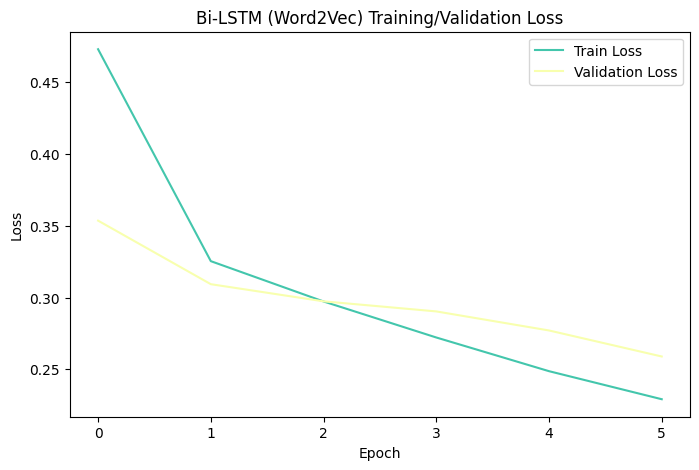

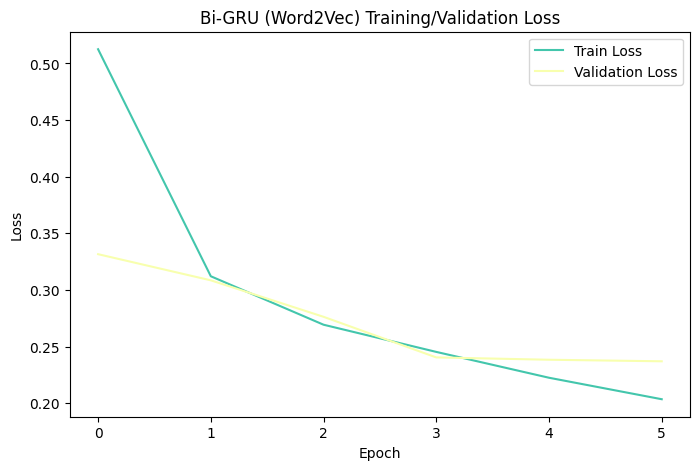

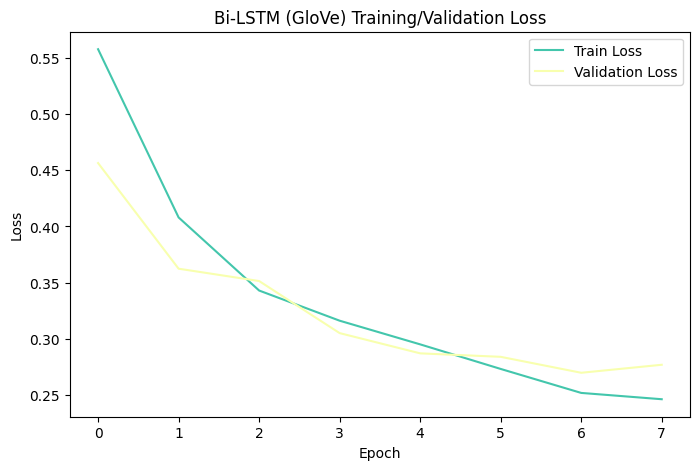

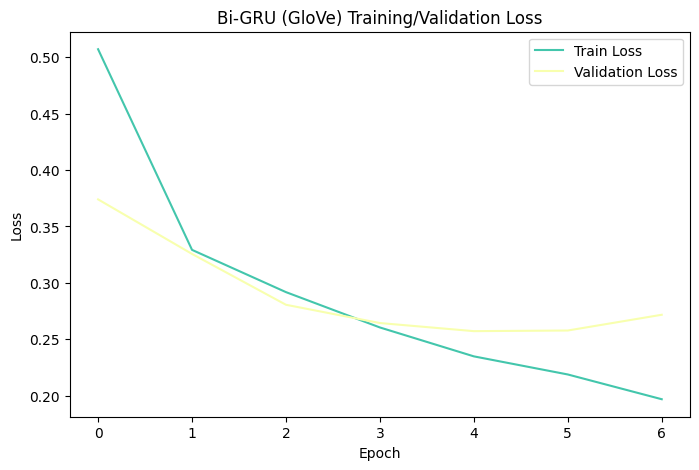

In [14]:
# Training/Validation Loss Graph for Deep Models
import matplotlib.pyplot as plt

# Plot training/validation loss for Bi-LSTM (Word2Vec)
if 'bilstm_w2v' in globals() and hasattr(bilstm_w2v, 'history') and bilstm_w2v.history is not None:
    history = bilstm_w2v.history.history
    plt.figure(figsize=(8,5))
    plt.plot(history['loss'], label='Train Loss', color='#43c6ac')
    plt.plot(history['val_loss'], label='Validation Loss', color='#f8ffae')
    plt.title('Bi-LSTM (Word2Vec) Training/Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Plot training/validation loss for Bi-GRU (Word2Vec)
if 'bigru_w2v' in globals() and hasattr(bigru_w2v, 'history') and bigru_w2v.history is not None:
    history = bigru_w2v.history.history
    plt.figure(figsize=(8,5))
    plt.plot(history['loss'], label='Train Loss', color='#43c6ac')
    plt.plot(history['val_loss'], label='Validation Loss', color='#f8ffae')
    plt.title('Bi-GRU (Word2Vec) Training/Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Plot training/validation loss for Bi-LSTM (GloVe)
if 'bilstm_glove' in globals() and hasattr(bilstm_glove, 'history') and bilstm_glove.history is not None:
    history = bilstm_glove.history.history
    plt.figure(figsize=(8,5))
    plt.plot(history['loss'], label='Train Loss', color='#43c6ac')
    plt.plot(history['val_loss'], label='Validation Loss', color='#f8ffae')
    plt.title('Bi-LSTM (GloVe) Training/Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Plot training/validation loss for Bi-GRU (GloVe)
if 'bigru_glove' in globals() and hasattr(bigru_glove, 'history') and bigru_glove.history is not None:
    history = bigru_glove.history.history
    plt.figure(figsize=(8,5))
    plt.plot(history['loss'], label='Train Loss', color='#43c6ac')
    plt.plot(history['val_loss'], label='Validation Loss', color='#f8ffae')
    plt.title('Bi-GRU (GloVe) Training/Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

In [15]:
# Print all results
print('Logistic Regression (BOW):', lr_bow_metrics)
print('SVM (BOW):', svm_bow_metrics)
print('Logistic Regression (TF-IDF):', lr_tfidf_metrics)
print('SVM (TF-IDF):', svm_tfidf_metrics)
print('Bi-LSTM (Word2Vec):', bilstm_w2v_metrics)
print('Bi-GRU (Word2Vec):', bigru_w2v_metrics)
if bilstm_glove_metrics is not None:
    print('Bi-LSTM (GloVe):', bilstm_glove_metrics)
    print('Bi-GRU (GloVe):', bigru_glove_metrics)
else:
    print('GloVe embeddings not available.')

Logistic Regression (BOW): (0.8132868487313577, 0.8398, 0.8263308078323329, 0.8235)
SVM (BOW): (0.8105040400153906, 0.8426, 0.8262404393018239, 0.8228)
Logistic Regression (TF-IDF): (0.8146341463414634, 0.835, 0.8246913580246914, 0.8225)
SVM (TF-IDF): (0.8121847109041521, 0.8372, 0.8245026590506205, 0.8218)
Bi-LSTM (Word2Vec): (0.9090338770388958, 0.8694, 0.8887753015743202, 0.8912)
Bi-GRU (Word2Vec): (0.9041206030150754, 0.8996, 0.9018546365914787, 0.9021)
Bi-LSTM (GloVe): (0.901089689857502, 0.86, 0.880065493246009, 0.8828)
Bi-GRU (GloVe): (0.8668180098373061, 0.9164, 0.8909196966750924, 0.8878)


In [20]:
from IPython.display import display, HTML

def display_results_box():
    rows = [
        ('Logistic Regression (BOW)', lr_bow_metrics),
        ('SVM (BOW)', svm_bow_metrics),
        ('Logistic Regression (TF-IDF)', lr_tfidf_metrics),
        ('SVM (TF-IDF)', svm_tfidf_metrics),
        ('Bi-LSTM (Word2Vec)', bilstm_w2v_metrics),
        ('Bi-GRU (Word2Vec)', bigru_w2v_metrics)
    ]
    if bilstm_glove_metrics is not None:
        rows.append(('Bi-LSTM (GloVe)', bilstm_glove_metrics))
        rows.append(('Bi-GRU (GloVe)', bigru_glove_metrics))
    else:
        rows.append(('Bi-LSTM (GloVe)', 'N/A'))
        rows.append(('Bi-GRU (GloVe)', 'N/A'))
    
    html = """<div style='border:2px solid #4CAF50; border-radius:8px; padding:16px; background:#f9f9f9; width:fit-content;'>"""
    html += "<h4>Model Results</h4>"
    html += "<table style='border-collapse:collapse;'>"
    html += "<tr><th style='border:1px solid #ccc;padding:6px;'>Model</th><th style='border:1px solid #ccc;padding:6px;'>Precision</th><th style='border:1px solid #ccc;padding:6px;'>Recall</th><th style='border:1px solid #ccc;padding:6px;'>F1</th><th style='border:1px solid #ccc;padding:6px;'>Accuracy</th></tr>"
    for name, metrics in rows:
        if metrics == 'N/A':
            html += f"<tr><td style='border:1px solid #ccc;padding:6px;'>{name}</td><td colspan='4' style='border:1px solid #ccc;padding:6px;'>N/A</td></tr>"
        else:
            p, r, f, a = [f"{x:.4f}" for x in metrics]
            html += f"<tr><td style='border:1px solid #ccc;padding:6px;'>{name}</td><td style='border:1px solid #ccc;padding:6px;'>{p}</td><td style='border:1px solid #ccc;padding:6px;'>{r}</td><td style='border:1px solid #ccc;padding:6px;'>{f}</td><td style='border:1px solid #ccc;padding:6px;'>{a}</td></tr>"
    html += "</table></div>"
    display(HTML(html))

display_results_box()

Model,Precision,Recall,F1,Accuracy
Logistic Regression (BOW),0.8133,0.8398,0.8263,0.8235
SVM (BOW),0.8105,0.8426,0.8262,0.8228
Logistic Regression (TF-IDF),0.8146,0.8350,0.8247,0.8225
SVM (TF-IDF),0.8122,0.8372,0.8245,0.8218
Bi-LSTM (Word2Vec),0.9090,0.8694,0.8888,0.8912
Bi-GRU (Word2Vec),0.9041,0.8996,0.9019,0.9021
Bi-LSTM (GloVe),0.9011,0.8600,0.8801,0.8828
Bi-GRU (GloVe),0.8668,0.9164,0.8909,0.8878


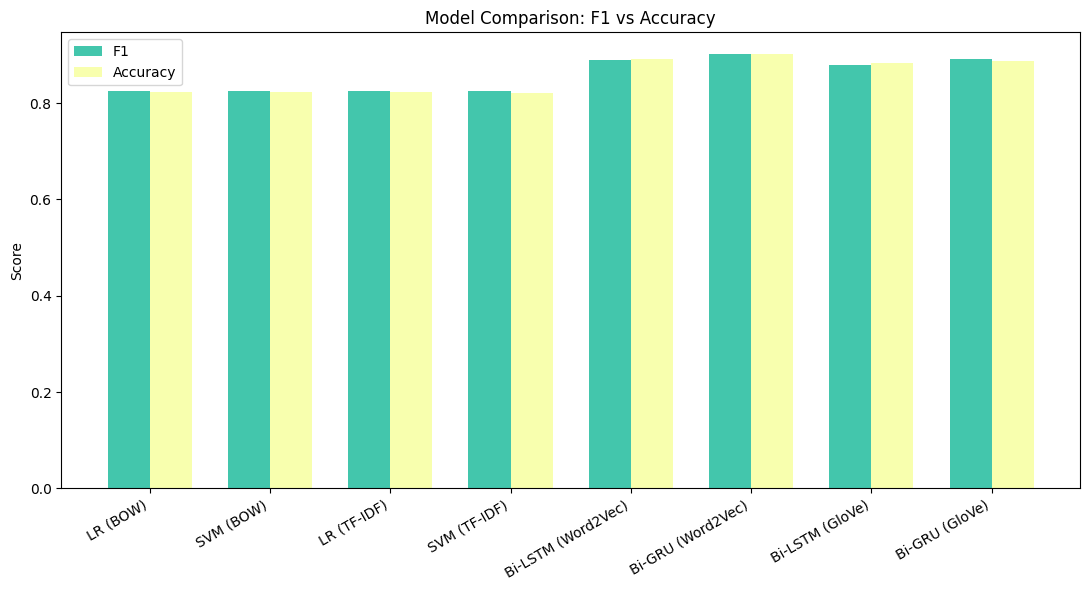

In [21]:
# Bar graph for F1 and Accuracy comparison
import matplotlib.pyplot as plt
import numpy as np

labels = [
    'LR (BOW)', 'SVM (BOW)', 'LR (TF-IDF)', 'SVM (TF-IDF)',
    'Bi-LSTM (Word2Vec)', 'Bi-GRU (Word2Vec)'
]
f1s = [lr_bow_metrics[2], svm_bow_metrics[2], lr_tfidf_metrics[2], svm_tfidf_metrics[2], bilstm_w2v_metrics[2], bigru_w2v_metrics[2]]
accs = [lr_bow_metrics[3], svm_bow_metrics[3], lr_tfidf_metrics[3], svm_tfidf_metrics[3], bilstm_w2v_metrics[3], bigru_w2v_metrics[3]]

# Add GloVe results if available
if 'bilstm_glove_metrics' in globals() and bilstm_glove_metrics is not None:
    labels += ['Bi-LSTM (GloVe)', 'Bi-GRU (GloVe)']
    f1s += [bilstm_glove_metrics[2], bigru_glove_metrics[2]]
    accs += [bilstm_glove_metrics[3], bigru_glove_metrics[3]]

x = np.arange(len(labels))
width = 0.35
fig, ax = plt.subplots(figsize=(11,6))
rects1 = ax.bar(x - width/2, f1s, width, label='F1', color='#43c6ac')
rects2 = ax.bar(x + width/2, accs, width, label='Accuracy', color='#f8ffae')
ax.set_ylabel('Score')
ax.set_title('Model Comparison: F1 vs Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right')
ax.legend()
plt.tight_layout()
plt.show()

In [3]:
! wget http://nlp.stanford.edu/data/glove.6B.zip
! unzip glove.6B.zip glove.6B.300d.txt

--2026-03-16 00:50:44--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-03-16 00:50:45--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-03-16 00:50:45--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov